<a href="https://colab.research.google.com/github/adityab-tech/Prism/blob/main/padchest_a.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving PADCHEST_chest_x_ray_images_labels_160K_01.02.19.csv.gz to PADCHEST_chest_x_ray_images_labels_160K_01.02.19.csv (4).gz


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("PADCHEST_chest_x_ray_images_labels_160K_01.02.19.csv.gz",compression="gzip",low_memory=False)
df.head().T

,0,1,2,3,4
Unnamed: 0,0,1,2,3,4
ImageID,20536686640136348236148679891455886468_k6ga29.png,135803415504923515076821959678074435083_fzis7d...,135803415504923515076821959678074435083_fzis7b...,113855343774216031107737439268243531979_3k951l...,113855343774216031107737439268243531979_3k951n...
ImageDir,0,0,0,0,0
StudyDate_DICOM,20140915,20150914,20150914,20150717,20150717
StudyID,20536686640136348236148679891455886468,135803415504923515076821959678074435083,135803415504923515076821959678074435083,113855343774216031107737439268243531979,113855343774216031107737439268243531979
PatientID,839860488694292331637988235681460987,313572750430997347502932654319389875966,313572750430997347502932654319389875966,50783093527901818115346441867348318648,50783093527901818115346441867348318648
PatientBirth,1930.0,1929.0,1929.0,1925.0,1925.0
PatientSex_DICOM,F,M,M,F,F
ViewPosition_DICOM,POSTEROANTERIOR,LATERAL,POSTEROANTERIOR,POSTEROANTERIOR,LATERAL
Projection,PA,L,PA,PA,L


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160861 entries, 0 to 160860
Data columns (total 36 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   Unnamed: 0                       160861 non-null  int64  
 1   ImageID                          160861 non-null  object 
 2   ImageDir                         160861 non-null  int64  
 3   StudyDate_DICOM                  160861 non-null  int64  
 4   StudyID                          160861 non-null  object 
 5   PatientID                        160861 non-null  object 
 6   PatientBirth                     160855 non-null  float64
 7   PatientSex_DICOM                 160857 non-null  object 
 8   ViewPosition_DICOM               91776 non-null   object 
 9   Projection                       160861 non-null  object 
 10  MethodProjection                 160861 non-null  object 
 11  Pediatric                        160861 non-null  object 
 12  Mo

In [5]:
df.describe()

,Unnamed: 0,ImageDir,StudyDate_DICOM,PatientBirth,PixelRepresentation_DICOM,SpatialResolution_DICOM,BitsStored_DICOM,WindowCenter_DICOM,WindowWidth_DICOM,Rows_DICOM,Columns_DICOM,XRayTubeCurrent_DICOM,Exposure_DICOM,ExposureInuAs_DICOM,ExposureTime,RelativeXRayExposure_DICOM,ReportID
count,160861.000000,160861.000000,1.608610e+05,160855.000000,160861.0,64268.000000,160861.000000,159638.000000,159638.000000,160861.000000,160861.000000,102876.000000,113444.000000,90288.000000,113444.000000,139407.000000,1.608610e+05
mean,80430.000000,25.788675,2.012297e+07,1953.674135,0.0,0.168671,11.791000,1964.942485,2844.801595,2254.351614,2299.083333,261.982241,4.160335,5513.987462,12.354677,281.308825,4.333135e+06
std,46436.715163,14.841329,2.317689e+04,20.027366,0.0,0.027178,0.611818,506.995759,1094.183891,736.263966,748.192714,163.268643,5.548866,5692.879916,14.724691,655.621171,5.066318e+05
min,0.000000,0.000000,2.007050e+07,1904.000000,0.0,0.100000,10.000000,511.500000,513.000000,636.000000,612.000000,0.000000,0.000000,500.000000,0.000000,-4.650000,3.204232e+06
25%,40215.000000,13.000000,2.010103e+07,1938.000000,0.0,0.143000,12.000000,2047.000000,2092.000000,1760.000000,1784.000000,250.000000,2.000000,2500.000000,5.000000,-0.970000,3.922806e+06
50%,80430.000000,26.000000,2.012062e+07,1950.000000,0.0,0.148000,12.000000,2047.000000,2370.000000,1916.000000,2000.000000,250.000000,2.000000,2500.000000,10.000000,0.920000,4.275856e+06
75%,120645.000000,38.000000,2.014053e+07,1966.000000,0.0,0.200000,12.000000,2139.000000,4095.000000,2735.000000,2788.000000,400.000000,3.000000,8000.000000,10.000000,396.000000,4.693279e+06
max,160860.000000,54.000000,2.017112e+07,2017.000000,0.0,0.200000,12.000000,3754.000000,4095.000000,4280.000000,4280.000000,640.000000,250.000000,250000.000000,1000.000000,43911.000000,5.519608e+06


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": (df.isnull().mean()*100).round(2)})
missing = missing.sort_values("Missing %", ascending=False)
display(missing)

,Missing Count,Missing %
PixelAspectRatio_DICOM,112858,70.16
SpatialResolution_DICOM,96593,60.05
ExposureInuAs_DICOM,70573,43.87
ViewPosition_DICOM,69085,42.95
XRayTubeCurrent_DICOM,57985,36.05
Exposure_DICOM,47417,29.48
ExposureTime,47417,29.48
RelativeXRayExposure_DICOM,21454,13.34
WindowWidth_DICOM,1223,0.76
WindowCenter_DICOM,1223,0.76


In [8]:
print("Duplicate rows :", df.duplicated().sum())
print("Duplicate ImageID :", df["ImageID"].duplicated().sum())
print("Duplicate PatientID :", df["PatientID"].duplicated().sum())
print("Duplicate StudyID :", df["StudyID"].duplicated().sum())
print("Duplicate ReportID :", df["ReportID"].duplicated().sum())

Duplicate rows : 0
Duplicate ImageID : 0
Duplicate PatientID : 93236
Duplicate StudyID : 50930
Duplicate ReportID : 53078


In [9]:
num_cols = df.select_dtypes(include=["int64","float64"]).columns
display(df[num_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,160861.0,8.043000e+04,46436.715163,0.00,4.021500e+04,8.043000e+04,120645.0,160860.0
ImageDir,160861.0,2.578867e+01,14.841329,0.00,1.300000e+01,2.600000e+01,38.0,54.0
StudyDate_DICOM,160861.0,2.012297e+07,23176.892872,20070503.00,2.010103e+07,2.012062e+07,20140528.0,20171117.0
PatientBirth,160855.0,1.953674e+03,20.027366,1904.00,1.938000e+03,1.950000e+03,1966.0,2017.0
PixelRepresentation_DICOM,160861.0,0.000000e+00,0.000000,0.00,0.000000e+00,0.000000e+00,0.0,0.0
SpatialResolution_DICOM,64268.0,1.686709e-01,0.027178,0.10,1.430000e-01,1.480000e-01,0.2,0.2
BitsStored_DICOM,160861.0,1.179100e+01,0.611818,10.00,1.200000e+01,1.200000e+01,12.0,12.0
WindowCenter_DICOM,159638.0,1.964942e+03,506.995759,511.50,2.047000e+03,2.047000e+03,2139.0,3754.0
WindowWidth_DICOM,159638.0,2.844802e+03,1094.183891,513.00,2.092000e+03,2.370000e+03,4095.0,4095.0
Rows_DICOM,160861.0,2.254352e+03,736.263966,636.00,1.760000e+03,1.916000e+03,2735.0,4280.0


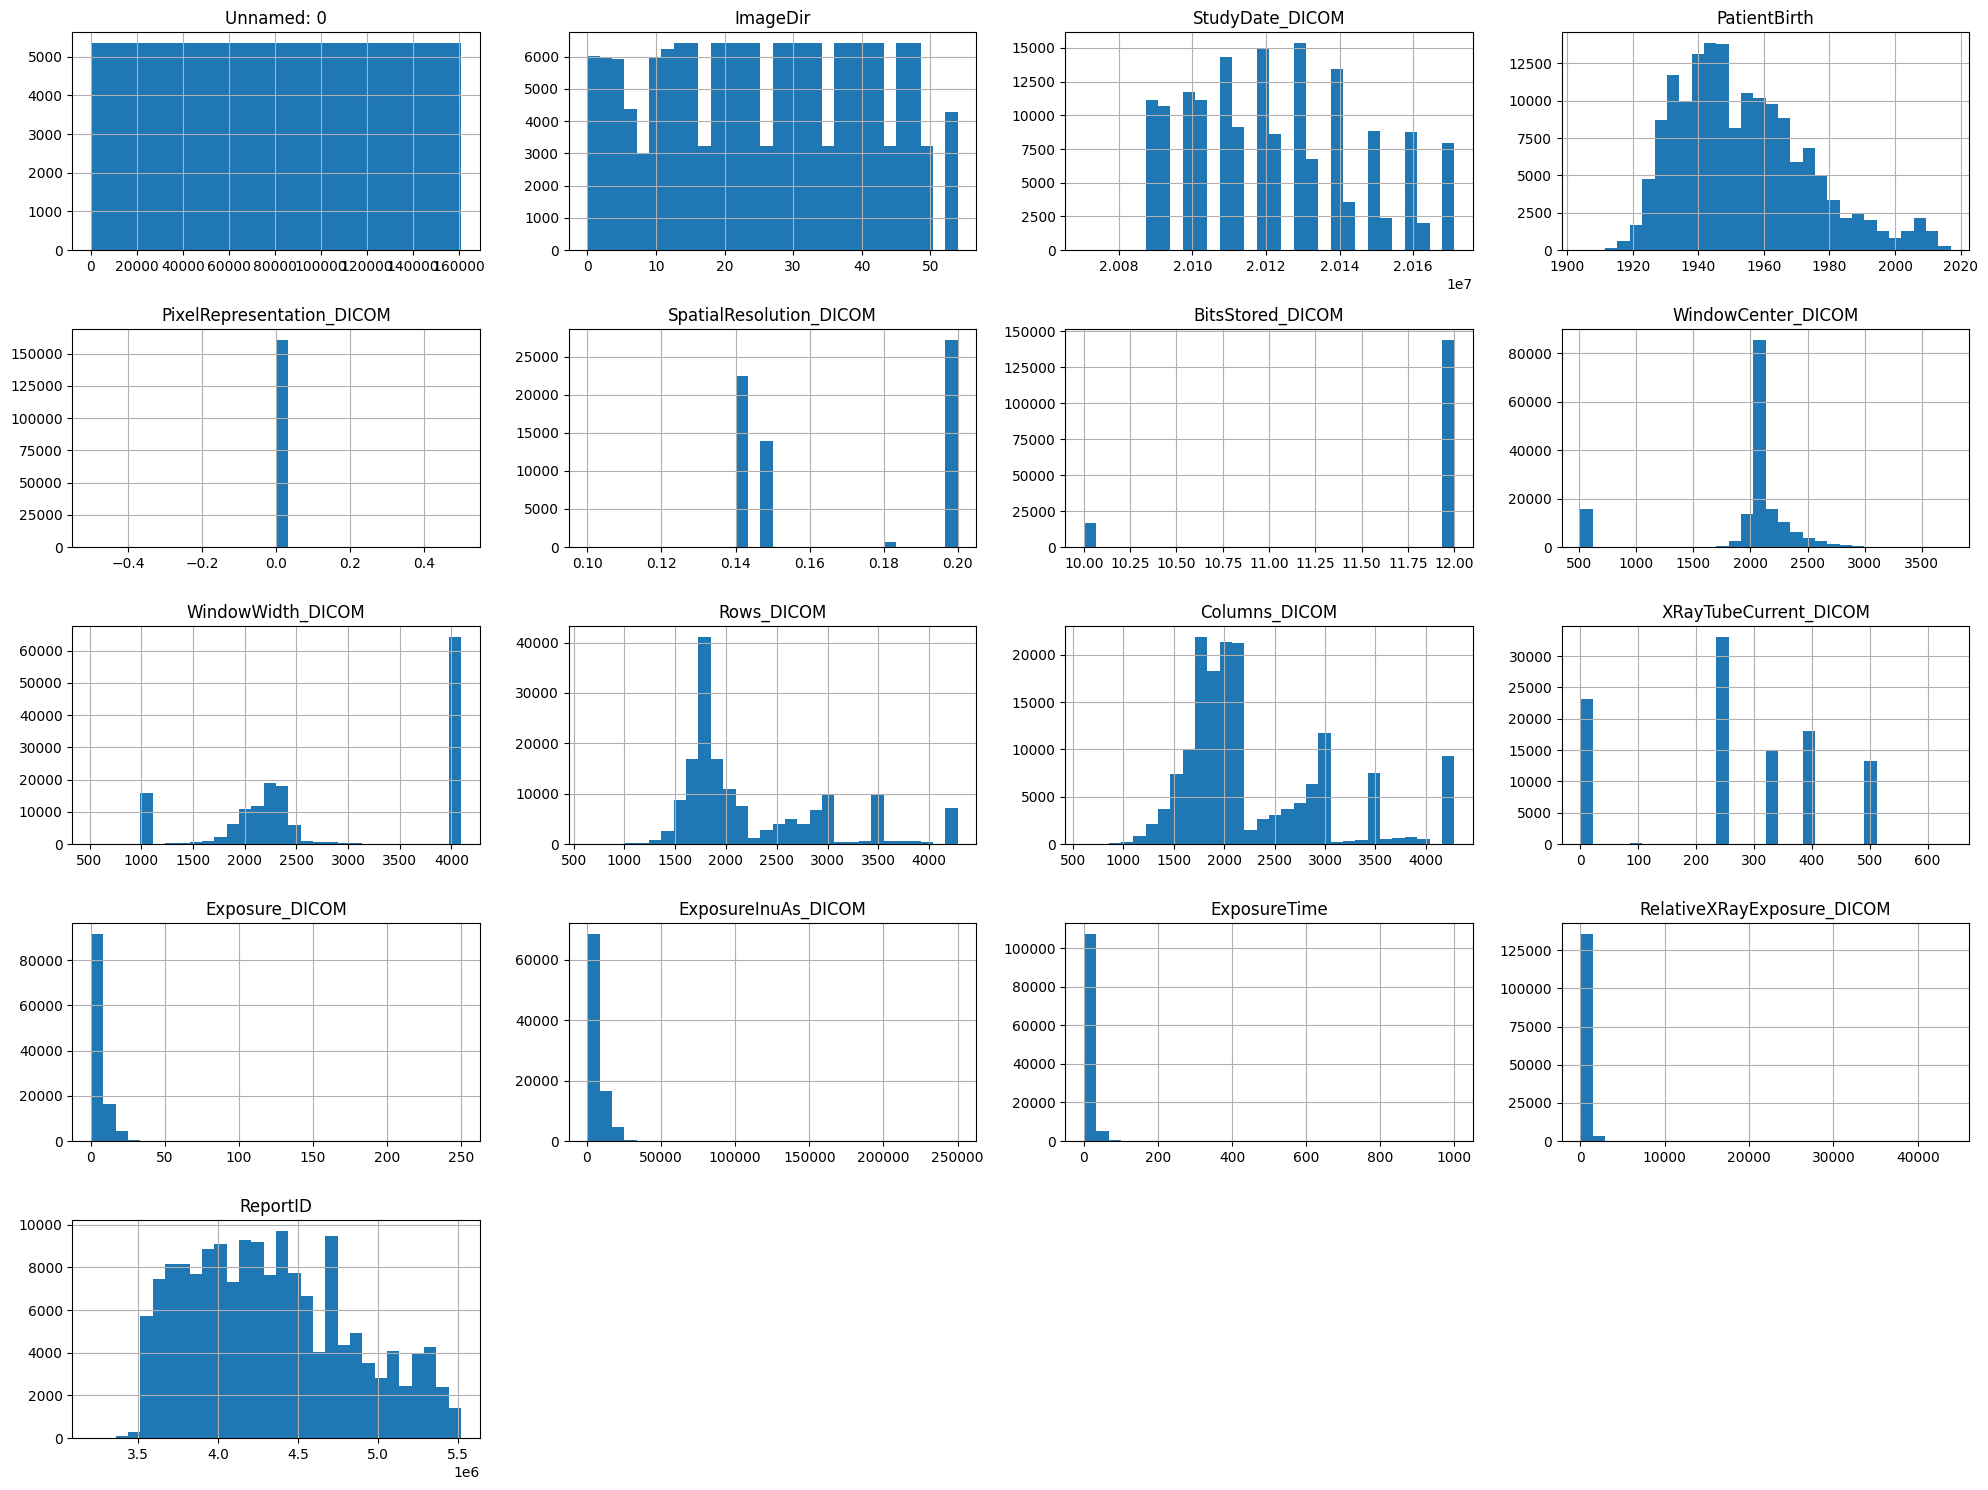

In [10]:
df[num_cols].hist(figsize=(20,15),bins=30)
plt.tight_layout()
plt.show()

In [11]:
#categorical columns
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    print(col)
    display(df[col].value_counts(dropna=False).head(20))
    print()

ImageID


,count
ImageID,
128401136192941452468211919169675154235144414526674_04-014-105.png,1
20536686640136348236148679891455886468_k6ga29.png,1
135803415504923515076821959678074435083_fzis7d.png,1
135803415504923515076821959678074435083_fzis7b.png,1
113855343774216031107737439268243531979_3k951l.png,1
113855343774216031107737439268243531979_3k951n.png,1
313903302629300007485735352869488750471_75sg0k.png,1
3137231742710829928-247610802266403640553_km0qf9.png,1
3137231742710829928-247610802266403640553_kine6a.png,1



StudyID


,count
StudyID,
234631815172402325214457183175747957599,11
216840111366964013590140476722013056123706310,11
12752243479320242271085,9
216840111366964013076187734852011269092353063,8
216840111366964013274515230432012031150854496,8
216840111366964012558082906712010097143705289,8
216840111366964013076187734852011252113036475,8
216840111366964013663026955732013112135435473,8
216840111366964013197700988782011301084140821,7



PatientID


...

,count
LabelsLocalizationsBySentence,
['normal'],32594
[['normal']],5540
"[['normal'], ['normal']]",5132
['COPD signs'],3304
['unchanged'],1424
['exclude'],1059
"['normal', 'loc cardiac']",953
"['normal', 'normal']",874
"['COPD signs', 'normal']",768



labelCUIS


,count
labelCUIS,
[],60801
['C0024117'],7618
['C0018800'],3047
['C0036439'],2988
['C0231819'],1498
['C2073625'],1406
['C0742362'],1282
['C0277877'],1164
['C0034079'],1065



LocalizationsCUIS


,count
LocalizationsCUIS,
[],67038
['C1522601'],6444
['C0003483'],3104
['C0003483' 'C1522601'],1851
['C0205150'],1309
['C0444532'],1290
['C0238767'],1208
['C1261074'],1134
['C0443246'],863


In [12]:
CURRENT_YEAR = 2017
df["Age"] = CURRENT_YEAR - df["PatientBirth"]
display(df["Age"].describe())

,Age
count,160855.000000
mean,63.325865
std,20.027366
min,0.000000
25%,51.000000
50%,67.000000
75%,79.000000
max,113.000000


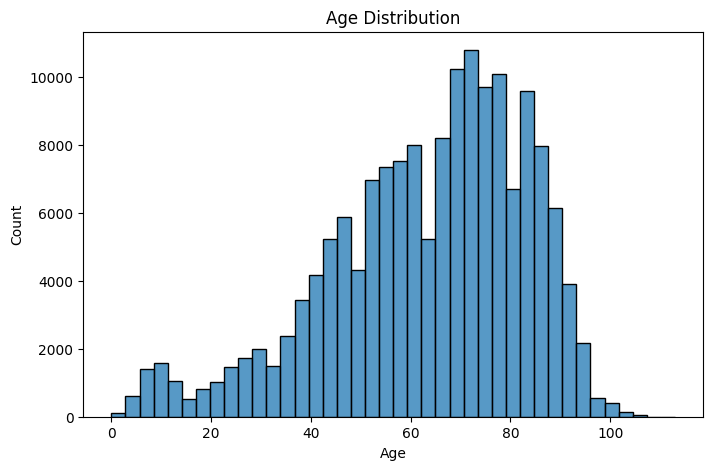

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=40)
plt.title("Age Distribution")
plt.show()

PatientSex_DICOM
M      80920
F      79919
O         18
NaN        4
Name: count, dtype: int64


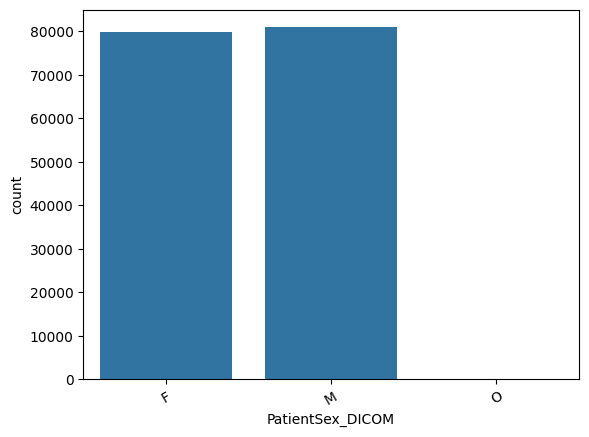

In [14]:
print(df["PatientSex_DICOM"].value_counts(dropna=False))
sns.countplot(data=df,
              x="PatientSex_DICOM")
plt.xticks(rotation=30)
plt.show()

Projection
PA               91728
L                49579
AP_horizontal    14346
AP                4559
COSTAL             630
EXCLUDE             11
UNK                  8
Name: count, dtype: int64
116


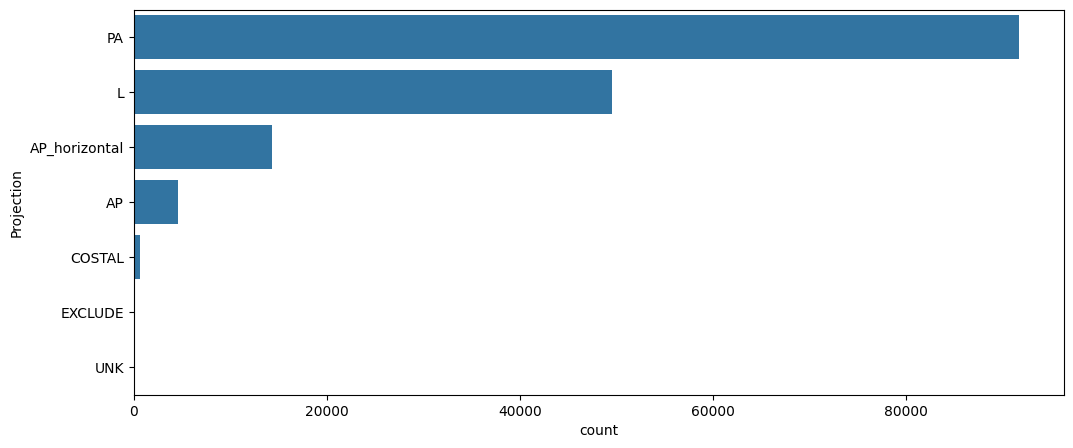

In [15]:
print(df["Projection"].value_counts())
plt.figure(figsize=(12,5))
sns.countplot(data=df,y="Projection",order=df["Projection"].value_counts().index)
print(df["Report"].isna().sum())
plt.show()

In [16]:
print(df["Report"].isna().sum())

116


In [17]:
df["report_length"] = df["Report"].fillna("").apply(len)
display(df["report_length"].describe())

,report_length
count,160861.000000
mean,94.349507
std,75.753194
min,0.000000
25%,35.000000
50%,74.000000
75%,134.000000
max,825.000000


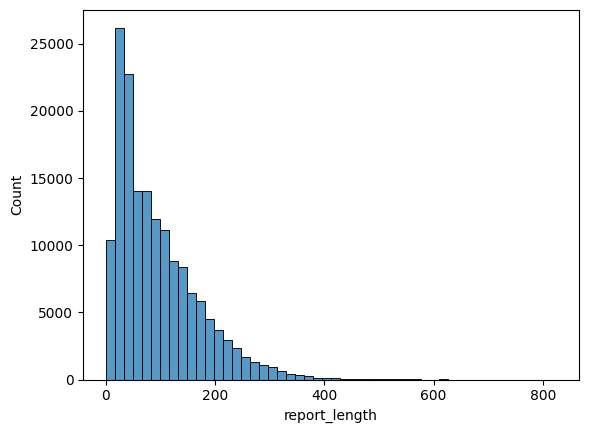

In [18]:
sns.histplot(df["report_length"],bins=50)
plt.show()

In [19]:
import ast
print(df["Labels"].isna().sum())
def parse_labels(x):
    if pd.isna(x) or x == "":
        return []
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return []
df["label_list"] = df["Labels"].apply(parse_labels)

103


In [20]:
from collections import Counter
counter = Counter()
for labels in df["label_list"]:
    counter.update(labels)
label_freq = pd.DataFrame(counter.items(),columns=["Disease","Count"]
)
label_freq = label_freq.sort_values("Count",ascending=False
)
display(label_freq.head(30))

,Disease,Count
0,normal,50340
25,COPD signs,23280
43,cardiomegaly,14535
6,unchanged,14207
19,aortic elongation,10348
20,scoliosis,7795
2,chronic changes,6999
66,costophrenic angle blunting,6412
10,pleural effusion,6273
15,infiltrates,5946


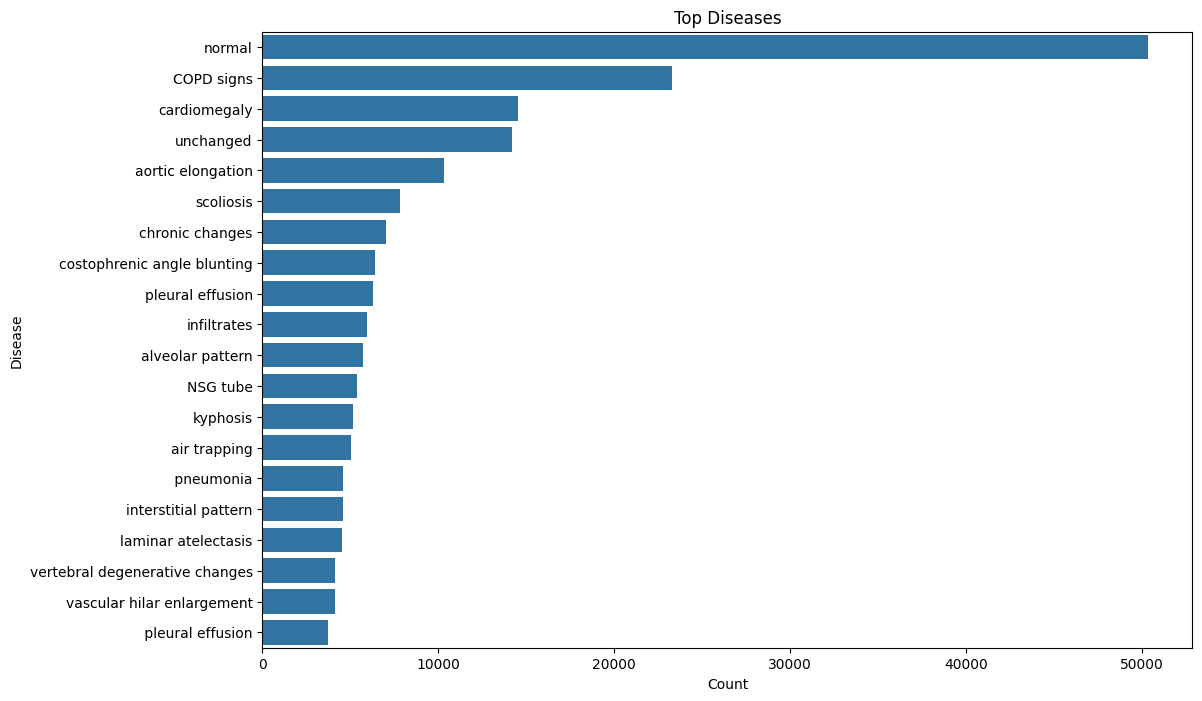

In [21]:
plt.figure(figsize=(12,8))
sns.barplot(data=label_freq.head(20),x="Count",y="Disease")
plt.title("Top Diseases")
plt.show()

In [22]:
patient_counts = df.groupby("PatientID").size()
display(patient_counts.describe())

,0
count,67625.000000
mean,2.378721
std,2.348779
min,1.000000
25%,1.000000
50%,2.000000
75%,2.000000
max,119.000000


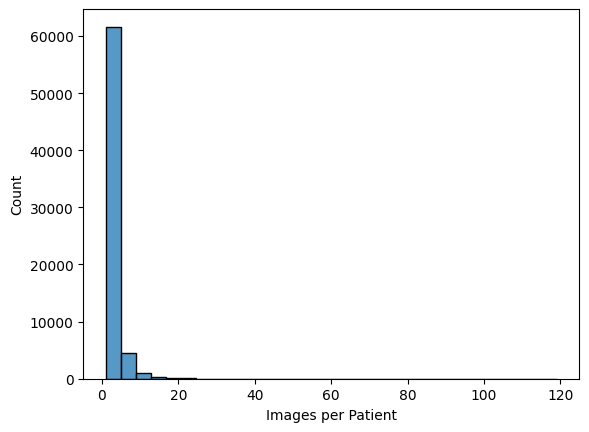

In [23]:
sns.histplot(patient_counts,bins=30)
plt.xlabel("Images per Patient")
plt.show()

In [24]:
# remove duplicate images
df = df.drop_duplicates(subset="ImageID")

# remove duplicate studies
df = df.drop_duplicates(subset="StudyID")

# remove impossible ages
df = df[(df["Age"]>=0) & (df["Age"]<=120)]

# remove missing labels
df = df[df["Labels"].notna()]

# remove missing reports
df = df[df["Report"].notna()]

In [25]:
df["num_labels"] = df["label_list"].apply(len)
df["hospital"] = "PadChest"
df["is_frontal"] = df["Projection"].isin(["PA","AP"])
df["report_words"] = (df["Report"].fillna("").str.split().str.len())

In [26]:
df.rename(columns={
    "ImageID":"image_id",
    "PatientID":"patient_id",
    "StudyID":"study_id",
    "PatientBirth":"birth_year",
    "PatientSex_DICOM":"sex",
    "Projection":"projection",
    "Report":"report",
    "Labels":"labels"
}, inplace=True)

In [27]:
df = df.drop_duplicates(subset="image_id")
df = df.drop_duplicates(subset="study_id")

In [28]:
label_freq["Percentage"] = (label_freq["Count"] /len(df))*100

In [29]:
#df["image_path"] = df["ImageDir"].astype(str).str.zfill(2) + "/" + df["ImageID"]

In [30]:
drop_cols = [
    "Unnamed: 0",
    "MethodProjection",
    "Manufacturer_DICOM",
    "PixelRepresentation_DICOM",
    "PixelAspectRatio_DICOM",
    "MethodLabel",
    "ReportID",
    "ImageDir",
    "labelCUIS",
    "LocalizationsCUIS",
    "LabelsLocalizationsBySentence",
    "Localizations"
]

df.drop(columns=drop_cols, inplace=True, errors="ignore")

In [31]:
df["Age"].isna().sum()
df = df[(df["Age"]>=0) & (df["Age"]<=120)]

In [32]:
df["sex"] = (df["sex"].fillna("Unknown").astype(str).str.upper().str.strip())
df["sex"] = df["sex"].replace({"M":"Male","F":"Female"})

In [33]:
import re

def clean_report(text):
    if pd.isna(text):
        return ""
    text=text.lower()
    text=re.sub(r"\n"," ",text)
    text=re.sub(r"\t"," ",text)
    text=re.sub(r"\s+"," ",text)
    return text.strip()

df["report"]=df["report"].apply(clean_report)
df = df[df["report"].str.len()>15]

In [34]:
df["labels"] = df["labels"].fillna("").str.lower()
df["label_list"] = df["label_list"].apply(lambda x: list(set(i.strip() for i in x if i!="")))

In [35]:
df = df[df["projection"].isin(["PA","AP"])]

In [36]:
df["num_labels"] = df["label_list"].apply(len)
df = df[df["num_labels"]>0]

In [37]:
from collections import Counter
counter = Counter()

for labels in df["label_list"]:
    counter.update(labels)
valid_labels = {
    k for k,v in counter.items()
    if v>=100
}

df["label_list"] = df["label_list"].apply(
    lambda x:[i for i in x if i in valid_labels]
)

df["num_labels"] = df["label_list"].apply(len)

df = df[df["num_labels"]>0]

In [38]:
from sklearn.model_selection import train_test_split
patients = df["patient_id"].unique()

# Pehle train vs (val+test) split karo
train_patients, temp_patients = train_test_split(
    patients, test_size=0.2, random_state=42
)

# Ab temp ko val aur test mein aadha-aadha baato
val_patients, test_patients = train_test_split(
    temp_patients, test_size=0.5, random_state=42
)

train_df = df[df["patient_id"].isin(train_patients)]
val_df = df[df["patient_id"].isin(val_patients)]
test_df = df[df["patient_id"].isin(test_patients)]

print(f"Train: {len(train_df)} rows, {len(train_patients)} patients")
print(f"Val:   {len(val_df)} rows, {len(val_patients)} patients")
print(f"Test:  {len(test_df)} rows, {len(test_patients)} patients")

Train: 47359 rows, 35462 patients
Val:   6000 rows, 4433 patients
Test:  5915 rows, 4433 patients


In [39]:
def labels_to_text(label_list):
    if not label_list or label_list == ["normal"]:
        return "No significant findings."
    return "Findings: " + ", ".join(label_list) + "."

df["text"] = df["label_list"].apply(labels_to_text)

In [40]:
train_df.to_csv("padchest_train.csv",index=False)
val_df.to_csv("padchest_val.csv",index=False)
test_df.to_csv("padchest_test.csv",index=False)

In [41]:
TARGET_LABELS = [
    "atelectasis",
    "cardiomegaly",
    "consolidation",
    "edema",
    "effusion",
    "opacity",
    "pneumonia",
    "pneumothorax",
    "fibrosis",
    "no finding"
]

In [42]:
for disease in TARGET_LABELS:
    df[disease] = df["label_list"].apply(
        lambda x: int(disease in x)
    )

In [43]:
ROOT="/content/PadChest/images"
df["image_path"]=ROOT+"/"+df["image_id"]

In [44]:
import os
df=df[df["image_path"].apply(os.path.exists)]